# VC-Genome: Proof-of-Concept (Stages 1–3)

Demonstrates the Visual Genome–inspired pipeline on 3 example images:
- **Low VC** — `wsj340.png` (Bar, VC=0.36)
- **Medium VC** — `VASTC.1.7.png` (Node-link, VC=0.70)
- **High VC** — `VisJ.1431.19.png` (Point, VC=0.80)

**Stage 1:** Structured extraction (objects, attributes, relationships) from existing participant comments  
**Stage 2:** Canonicalization against the 21-subtopic ontology  
**Stage 3:** Graph assembly — region graphs per comment, merged into scene graphs per image

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from collections import defaultdict, Counter

pd.set_option('display.max_colwidth', 120)

## Load Source Data

In [16]:
# Load the compiled phrases table
compiled = pd.read_csv('phrase_reduction_v2/image_compiled_phrases.csv')

# Load the 21-subtopic ontology
subtopics_df = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')

# Select our 3 example images
EXAMPLE_IMAGES = ['wsj340.png', 'VASTC.1.7.png', 'VisJ.1431.19.png']
examples = compiled[compiled['imageName'].isin(EXAMPLE_IMAGES)].copy()
examples = examples.set_index('imageName').loc[EXAMPLE_IMAGES].reset_index()

print(f"Selected {len(examples)} images:")
for _, r in examples.iterrows():
    n_comments = len(str(r['rawUserComments']).split(';'))
    print(f"  {r['imageName']:25s}  {r['VisType']:12s}  VC={r['NormalizedVC']:.2f}  ({n_comments} comments)")

Selected 3 images:
  wsj340.png                 Bar           VC=0.36  (2 comments)
  VASTC.1.7.png              Node-link     VC=0.70  (14 comments)
  VisJ.1431.19.png           Point         VC=0.80  (1 comments)


In [17]:
# Display the 19 subtopics that form our ontology
print("Subtopic Ontology (19 named subtopics across 7 topics):")
print("=" * 80)
for topic, grp in subtopics_df.groupby('Topic', sort=False):
    print(f"\n{topic}")
    for _, row in grp.iterrows():
        print(f"  • {row['SubTopic']:35s} {row['Description'][:70]}")

Subtopic Ontology (19 named subtopics across 7 topics):

Data Density / Image Clutter
  • Information Volume                  The perceived amount, richness, or depth of data content in the image 
  • Element Quantity                    The number of discrete graphical elements (points, lines, bars, shapes
  • Visual Clutter & Overlap            Spatial density, overlapping elements, layout congestion, and use (or 

Visual Encoding Clarity
  • Graphical Forms & Primitives        The variety, type, and physical attributes of shapes, lines, and mark 
  • Position, Scale & Organization      Spatial layout, alignment, ordering, scale consistency, and structural
  • Encoding Interpretability           Whether visual encodings convey clear, decodable meaning — including r

Semantics / Text Legibility
  • Annotations & Labels                Presence, clarity, and sufficiency of titles, axis labels, legends, ca
  • Text Volume & Content               The quantity of text, numbers, or contextua

---
## Stage 1: Structured Extraction

In production, Claude would extract these from the raw comments + image.
Here we manually construct the structured annotations to demonstrate the data model.

Each image gets:
- **VC-Objects**: named visual elements, assigned to a canonical region
- **VC-Attributes**: complexity-relevant properties of objects, with sentiment
- **VC-Relationships**: directed triplets connecting objects/attributes

In [18]:
# ============================================================
# Stage 1: Manually constructed structured extractions
# (In production, Claude generates these from comments + image)
# ============================================================

# Canonical visualization regions
REGIONS = ['data_area', 'x_axis', 'y_axis', 'legend', 'title',
           'annotations', 'background', 'whitespace', 'overall']

stage1_extractions = {}

# ---------------------------------------------------------------
# Image 1: wsj340.png — Bar chart, VC = 0.36 (low complexity)
# Comments mention: title, description, labels, coloured segments,
#   variety of elements, level of detail, depth/dimensionality
# ---------------------------------------------------------------
stage1_extractions['wsj340.png'] = {
    'objects': [
        {'id': 1, 'name': 'bar',             'region': 'data_area'},
        {'id': 2, 'name': 'title',           'region': 'title'},
        {'id': 3, 'name': 'description',     'region': 'annotations'},
        {'id': 4, 'name': 'axis_label',      'region': 'x_axis'},
        {'id': 5, 'name': 'color_segment',   'region': 'data_area'},
        {'id': 6, 'name': 'legend',          'region': 'legend'},
    ],
    'attributes': [
        {'object_id': 1, 'attr': 'horizontal',       'sentiment': '+', 'subtopic': 'Graphical Forms & Primitives'},
        {'object_id': 5, 'attr': 'coloured',         'sentiment': '-', 'subtopic': 'Color Palette & Contrast'},
        {'object_id': 5, 'attr': 'well_segmented',   'sentiment': '-', 'subtopic': 'Color Palette & Contrast'},
        {'object_id': 2, 'attr': 'present',          'sentiment': '-', 'subtopic': 'Annotations & Labels'},
        {'object_id': 3, 'attr': 'present',          'sentiment': '-', 'subtopic': 'Annotations & Labels'},
        {'object_id': 4, 'attr': 'readable',         'sentiment': '-', 'subtopic': 'Typography & Readability'},
        {'object_id': 6, 'attr': 'clear',            'sentiment': '-', 'subtopic': 'Domain Familiarity'},
    ],
    'relationships': [
        {'subj': 2, 'pred': 'describes',       'obj': 1, 'sentiment': '-', 'subtopic': 'Annotations & Labels'},
        {'subj': 5, 'pred': 'encodes_via',     'obj': 1, 'sentiment': '-', 'subtopic': 'Color Palette & Contrast'},
        {'subj': 6, 'pred': 'clarifies',       'obj': 5, 'sentiment': '-', 'subtopic': 'Encoding Interpretability'},
        {'subj': 4, 'pred': 'labels',          'obj': 1, 'sentiment': '-', 'subtopic': 'Annotations & Labels'},
    ]
}

# ---------------------------------------------------------------
# Image 2: VASTC.1.7.png — Node-link, VC = 0.70 (medium-high)
# Comments: abundance of objects, variation in colours, vertical
#   lines, contrasting patterns, fine/intricate details, dots hard
#   to understand, arbitrary imaging, confusing connections,
#   no details on color code
# ---------------------------------------------------------------
stage1_extractions['VASTC.1.7.png'] = {
    'objects': [
        {'id': 1, 'name': 'dot',              'region': 'data_area'},
        {'id': 2, 'name': 'vertical_line',    'region': 'data_area'},
        {'id': 3, 'name': 'color_code',       'region': 'legend'},
        {'id': 4, 'name': 'box',              'region': 'data_area'},
        {'id': 5, 'name': 'pattern',          'region': 'data_area'},
        {'id': 6, 'name': 'connection',       'region': 'data_area'},
    ],
    'attributes': [
        {'object_id': 1, 'attr': 'abundant',         'sentiment': '+', 'subtopic': 'Element Quantity'},
        {'object_id': 1, 'attr': 'fine_grained',     'sentiment': '+', 'subtopic': 'Information Volume'},
        {'object_id': 2, 'attr': 'numerous',         'sentiment': '+', 'subtopic': 'Element Quantity'},
        {'object_id': 3, 'attr': 'unclear',          'sentiment': '+', 'subtopic': 'Color Palette & Contrast'},
        {'object_id': 4, 'attr': 'significantly_different', 'sentiment': '+', 'subtopic': 'Visual Disorganization'},
        {'object_id': 5, 'attr': 'contrasting',      'sentiment': '+', 'subtopic': 'Color Palette & Contrast'},
        {'object_id': 5, 'attr': 'intricate',        'sentiment': '+', 'subtopic': 'Information Volume'},
        {'object_id': 6, 'attr': 'confusing',        'sentiment': '+', 'subtopic': 'Semantic Clarity'},
    ],
    'relationships': [
        {'subj': 1, 'pred': 'fills',            'obj': 4, 'sentiment': '+', 'subtopic': 'Visual Clutter & Overlap'},
        {'subj': 5, 'pred': 'varies_across',    'obj': 4, 'sentiment': '+', 'subtopic': 'Visual Disorganization'},
        {'subj': 6, 'pred': 'connects',         'obj': 1, 'sentiment': '+', 'subtopic': 'Graphical Forms & Primitives'},
        {'subj': 3, 'pred': 'fails_to_explain', 'obj': 1, 'sentiment': '+', 'subtopic': 'Encoding Interpretability'},
        {'subj': 1, 'pred': 'obscures',         'obj': 5, 'sentiment': '+', 'subtopic': 'Perceptual Ambiguity'},
        {'subj': 2, 'pred': 'overlaps_with',    'obj': 1, 'sentiment': '+', 'subtopic': 'Visual Clutter & Overlap'},
    ]
}

# ---------------------------------------------------------------
# Image 3: VisJ.1431.19.png — Point/scatter, VC = 0.80 (high)
# Comments: scattered shapes, hard to make sense of, different
#   shapes, unfamiliar visualization, hard to see the story,
#   a lot going on, not neat
# ---------------------------------------------------------------
stage1_extractions['VisJ.1431.19.png'] = {
    'objects': [
        {'id': 1, 'name': 'dot',              'region': 'data_area'},
        {'id': 2, 'name': 'shape',            'region': 'data_area'},
        {'id': 3, 'name': 'data_pattern',     'region': 'data_area'},
        {'id': 4, 'name': 'layout',           'region': 'overall'},
        {'id': 5, 'name': 'visualization',    'region': 'overall'},
    ],
    'attributes': [
        {'object_id': 1, 'attr': 'scattered',       'sentiment': '+', 'subtopic': 'Visual Clutter & Overlap'},
        {'object_id': 2, 'attr': 'varied',          'sentiment': '+', 'subtopic': 'Graphical Forms & Primitives'},
        {'object_id': 2, 'attr': 'numerous',        'sentiment': '+', 'subtopic': 'Element Quantity'},
        {'object_id': 3, 'attr': 'unclear',         'sentiment': '+', 'subtopic': 'Semantic Clarity'},
        {'object_id': 4, 'attr': 'messy',           'sentiment': '+', 'subtopic': 'Visual Disorganization'},
        {'object_id': 5, 'attr': 'unfamiliar',      'sentiment': '+', 'subtopic': 'Domain Familiarity'},
        {'object_id': 5, 'attr': 'hard_to_read',    'sentiment': '+', 'subtopic': 'Interpretive Difficulty'},
    ],
    'relationships': [
        {'subj': 1, 'pred': 'scattered_across',  'obj': 4, 'sentiment': '+', 'subtopic': 'Visual Clutter & Overlap'},
        {'subj': 2, 'pred': 'mixed_with',        'obj': 1, 'sentiment': '+', 'subtopic': 'Element Quantity'},
        {'subj': 3, 'pred': 'lacks_story',       'obj': 5, 'sentiment': '+', 'subtopic': 'Semantic Clarity'},
        {'subj': 5, 'pred': 'requires_expertise','obj': 3, 'sentiment': '+', 'subtopic': 'Domain Familiarity'},
        {'subj': 4, 'pred': 'overwhelms',        'obj': 5, 'sentiment': '+', 'subtopic': 'Processing Time & Effort'},
    ]
}

# Show summary
for img, data in stage1_extractions.items():
    vc = examples.loc[examples['imageName']==img, 'NormalizedVC'].values[0]
    print(f"{img} (VC={vc:.2f}): {len(data['objects'])} objects, "
          f"{len(data['attributes'])} attributes, {len(data['relationships'])} relationships")

wsj340.png (VC=0.36): 6 objects, 7 attributes, 4 relationships
VASTC.1.7.png (VC=0.70): 6 objects, 8 attributes, 6 relationships
VisJ.1431.19.png (VC=0.80): 5 objects, 7 attributes, 5 relationships


### Stage 1 Output: Examining the Extractions

In [19]:
# Display the raw extraction for each image
for img, data in stage1_extractions.items():
    row = examples[examples['imageName']==img].iloc[0]
    print(f"\n{'='*80}")
    print(f"{img}  |  {row['VisType']}  |  VC = {row['NormalizedVC']}")
    print(f"{'='*80}")
    
    print(f"\nParticipant comments:")
    for c in str(row['rawUserComments']).split(';'):
        c = c.strip()
        if c:
            print(f"  « {c} »")
    
    print(f"\nVC-Objects:")
    for o in data['objects']:
        print(f"  [{o['id']}] {o['name']:20s}  @ {o['region']}")
    
    print(f"\nVC-Attributes:")
    for a in data['attributes']:
        obj_name = next(o['name'] for o in data['objects'] if o['id'] == a['object_id'])
        print(f"  ({a['sentiment']}) {obj_name}.{a['attr']:25s}  → {a['subtopic']}")

    print(f"\nVC-Relationships:")
    for r in data['relationships']:
        s_name = next(o['name'] for o in data['objects'] if o['id'] == r['subj'])
        o_name = next(o['name'] for o in data['objects'] if o['id'] == r['obj'])
        print(f"  ({r['sentiment']}) {s_name} —[{r['pred']}]→ {o_name}  → {r['subtopic']}")


wsj340.png  |  Bar  |  VC = 0.36

Participant comments:
  « The right image is a chart with a title, description, labels and coloured segments, therefore it doesn't need to do as much visually. »
  « 1. Variety and Density of Elements, 2.Level of Detail 3. Depth and Dimensionality and 4.Interconnectedness of Elements. »

VC-Objects:
  [1] bar                   @ data_area
  [2] title                 @ title
  [3] description           @ annotations
  [4] axis_label            @ x_axis
  [5] color_segment         @ data_area
  [6] legend                @ legend

VC-Attributes:
  (+) bar.horizontal                 → Graphical Forms & Primitives
  (-) color_segment.coloured                   → Color Palette & Contrast
  (-) color_segment.well_segmented             → Color Palette & Contrast
  (-) title.present                    → Annotations & Labels
  (-) description.present                    → Annotations & Labels
  (-) axis_label.readable                   → Typography & Readability

---
## Stage 2: Canonicalization

Map all extracted elements to the controlled vocabulary:
- Object names → canonical object synsets
- Attribute names → standardized terms
- Relationship predicates → controlled predicate set
- All elements verified against the 21-subtopic ontology

In [20]:
# ============================================================
# Stage 2: Canonicalization
# ============================================================

# Object synonym map (like VG's WordNet synset mapping)
OBJECT_SYNSETS = {
    # data marks
    'bar': 'mark.bar', 'dot': 'mark.point', 'point': 'mark.point',
    'shape': 'mark.shape', 'line': 'mark.line', 'vertical_line': 'mark.line',
    'color_segment': 'mark.color_segment',
    # structural
    'box': 'structure.panel', 'layout': 'structure.layout',
    'pattern': 'structure.pattern', 'data_pattern': 'structure.pattern',
    'connection': 'structure.link',
    # text/annotation
    'title': 'text.title', 'description': 'text.description',
    'axis_label': 'text.axis_label', 'label': 'text.label',
    # furniture
    'legend': 'furniture.legend', 'color_code': 'furniture.legend',
    # whole
    'visualization': 'whole.visualization',
}

# Predicate normalization
PREDICATE_CANON = {
    'describes': 'describes', 'labels': 'describes', 'clarifies': 'clarifies',
    'encodes_via': 'encodes_via',
    'fills': 'fills', 'overlaps_with': 'overlaps_with',
    'varies_across': 'varies_across',
    'connects': 'connects',
    'fails_to_explain': 'fails_to_explain',
    'obscures': 'obscures',
    'scattered_across': 'distributed_across',
    'mixed_with': 'co_occurs_with',
    'lacks_story': 'lacks_meaning_for',
    'requires_expertise': 'requires_expertise_for',
    'overwhelms': 'overwhelms',
}

# Attribute normalization
ATTR_CANON = {
    'horizontal': 'horizontal', 'coloured': 'colored', 'well_segmented': 'well_segmented',
    'present': 'present', 'readable': 'readable', 'clear': 'clear',
    'abundant': 'numerous', 'numerous': 'numerous', 'fine_grained': 'fine_grained',
    'unclear': 'unclear', 'significantly_different': 'highly_varied',
    'contrasting': 'contrasting', 'intricate': 'intricate', 'confusing': 'confusing',
    'scattered': 'scattered', 'varied': 'varied', 'messy': 'disorganized',
    'unfamiliar': 'unfamiliar', 'hard_to_read': 'hard_to_interpret',
}


def canonicalize(extraction):
    """Apply canonicalization to a Stage 1 extraction."""
    canon = {'objects': [], 'attributes': [], 'relationships': []}
    
    # Canonicalize objects
    id_map = {}  # old_id -> new canonical name
    for obj in extraction['objects']:
        synset = OBJECT_SYNSETS.get(obj['name'], f"unknown.{obj['name']}")
        id_map[obj['id']] = synset
        canon['objects'].append({
            'id': obj['id'], 'name': obj['name'],
            'synset': synset, 'region': obj['region']
        })
    
    # Canonicalize attributes
    for attr in extraction['attributes']:
        canon['attributes'].append({
            'object_id': attr['object_id'],
            'object_synset': id_map[attr['object_id']],
            'attr': ATTR_CANON.get(attr['attr'], attr['attr']),
            'sentiment': attr['sentiment'],
            'subtopic': attr['subtopic'],
        })
    
    # Canonicalize relationships
    for rel in extraction['relationships']:
        canon['relationships'].append({
            'subject_synset': id_map[rel['subj']],
            'predicate': PREDICATE_CANON.get(rel['pred'], rel['pred']),
            'object_synset': id_map[rel['obj']],
            'sentiment': rel['sentiment'],
            'subtopic': rel['subtopic'],
        })
    
    return canon


# Apply canonicalization
stage2_canonical = {}
for img, extraction in stage1_extractions.items():
    stage2_canonical[img] = canonicalize(extraction)

# Show canonicalized result for one example
img = 'VASTC.1.7.png'
print(f"Canonicalized: {img}\n")
print("Objects:")
for o in stage2_canonical[img]['objects']:
    print(f"  {o['name']:20s} → {o['synset']}")
print("\nRelationships:")
for r in stage2_canonical[img]['relationships']:
    print(f"  ({r['sentiment']}) {r['subject_synset']} —[{r['predicate']}]→ {r['object_synset']}")

Canonicalized: VASTC.1.7.png

Objects:
  dot                  → mark.point
  vertical_line        → mark.line
  color_code           → furniture.legend
  box                  → structure.panel
  pattern              → structure.pattern
  connection           → structure.link

Relationships:
  (+) mark.point —[fills]→ structure.panel
  (+) structure.pattern —[varies_across]→ structure.panel
  (+) structure.link —[connects]→ mark.point
  (+) furniture.legend —[fails_to_explain]→ mark.point
  (+) mark.point —[obscures]→ structure.pattern
  (+) mark.line —[overlaps_with]→ mark.point


---
## Stage 3: Graph Assembly

Build a **VC-Scene Graph** per image:
- Nodes = VC-Objects (with attributes attached)
- Edges = VC-Relationships (directed, labeled)
- Node color = dominant sentiment
- Edge labels = predicate

In [21]:
# ============================================================
# Stage 3: Build scene graphs using NetworkX
# ============================================================

# Topic -> color mapping for visualization
TOPIC_COLORS = {
    'Data Density / Image Clutter': '#e74c3c',
    'Visual Encoding Clarity': '#3498db',
    'Semantics / Text Legibility': '#2ecc71',
    'Schema': '#9b59b6',
    'Color, Symbol, and Texture Details': '#f39c12',
    'Aesthetics Uncertainty': '#e67e22',
    'Immediacy / Cognitive Load': '#1abc9c',
}

# Subtopic -> parent topic lookup
SUBTOPIC_TO_TOPIC = dict(zip(subtopics_df['SubTopic'], subtopics_df['Topic']))


def build_scene_graph(canon_data, image_name):
    """Build a NetworkX DiGraph from canonicalized extraction."""
    G = nx.DiGraph()
    G.graph['image'] = image_name

    # Add object nodes
    for obj in canon_data['objects']:
        node_id = obj['synset']
        G.add_node(node_id,
                   label=obj['name'],
                   synset=obj['synset'],
                   region=obj['region'],
                   node_type='object',
                   attributes=[],
                   sentiments=[])

    # Attach attributes to nodes
    for attr in canon_data['attributes']:
        node_id = attr['object_synset']
        if node_id in G:
            G.nodes[node_id]['attributes'].append(attr['attr'])
            G.nodes[node_id]['sentiments'].append(attr['sentiment'])

    # Add relationship edges
    for rel in canon_data['relationships']:
        G.add_edge(
            rel['subject_synset'],
            rel['object_synset'],
            predicate=rel['predicate'],
            sentiment=rel['sentiment'],
            subtopic=rel['subtopic'],
            topic=SUBTOPIC_TO_TOPIC.get(rel['subtopic'], 'Unknown'),
        )

    return G


# Build all scene graphs
scene_graphs = {}
for img, canon in stage2_canonical.items():
    scene_graphs[img] = build_scene_graph(canon, img)

# Summary metrics
print(f"{'Image':<25s} {'VC':>5s} {'Nodes':>6s} {'Edges':>6s} {'Attrs':>6s} {'(+)%':>6s}")
print("-" * 60)
for img in EXAMPLE_IMAGES:
    G = scene_graphs[img]
    vc = examples.loc[examples['imageName']==img, 'NormalizedVC'].values[0]
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    all_sents = [s for n in G.nodes for s in G.nodes[n].get('sentiments', [])]
    all_sents += [G.edges[e]['sentiment'] for e in G.edges]
    n_attrs = sum(len(G.nodes[n].get('attributes', [])) for n in G.nodes)
    pos_pct = sum(1 for s in all_sents if s == '+') / max(len(all_sents), 1) * 100
    print(f"{img:<25s} {vc:>5.2f} {n_nodes:>6d} {n_edges:>6d} {n_attrs:>6d} {pos_pct:>5.1f}%")

Image                        VC  Nodes  Edges  Attrs   (+)%
------------------------------------------------------------
wsj340.png                 0.36      6      4      7   9.1%
VASTC.1.7.png              0.70      6      6      8 100.0%
VisJ.1431.19.png           0.80      5      5      7 100.0%


### Visualize the Scene Graphs

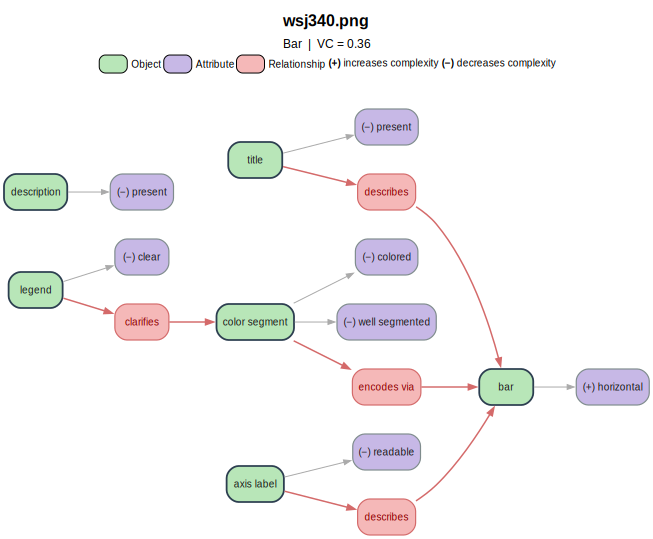

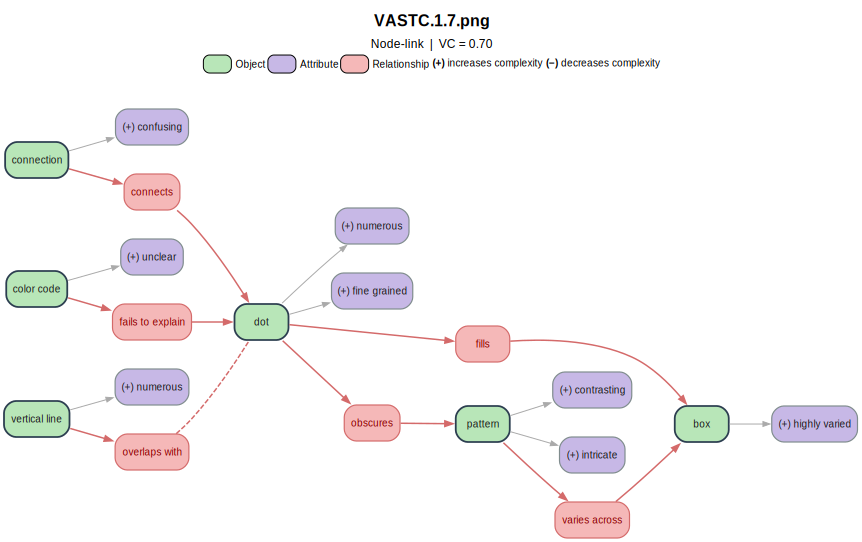

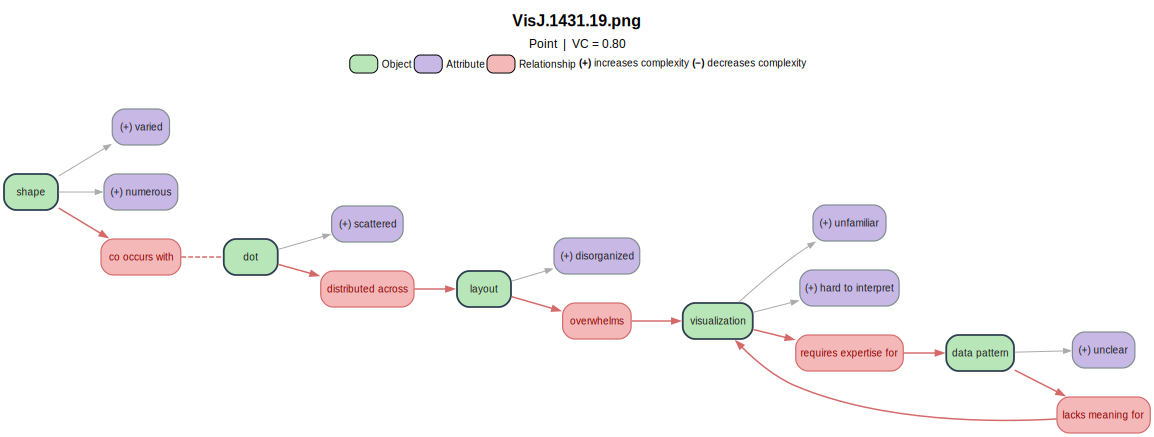

In [30]:
# ============================================================
# VG-style directed scene graphs using Graphviz
# Layout: objects (green) → attributes (purple) with arrows
# Relationships shown as intermediate pink nodes between objects
# ============================================================
import os, sys, graphviz
from IPython.display import display, SVG, HTML

# Ensure Graphviz binaries are on PATH for this kernel session
os.environ['PATH'] = r'C:\Program Files (x86)\Graphviz\bin;' + os.environ.get('PATH', '')

# Suppress Pango-CRITICAL warnings from Graphviz on Windows
os.environ['PANGOCAIRO_BACKEND'] = 'fontconfig'

COLOR_OBJECT = '#b8e6b8'       # light green
COLOR_ATTRIBUTE = '#c7b8e6'    # light purple
COLOR_RELATION = '#f5b8b8'     # light pink

UNDIRECTED_PREDS = {'co_occurs_with', 'overlaps_with'}


def build_vg_graphviz(canon_data, image_name, vc, vistype):
    """Build a Graphviz Digraph matching the Visual Genome paper style."""
    dot = graphviz.Digraph(
        name=image_name,
        format='svg',
        graph_attr={
            'rankdir': 'LR',          # left-to-right like VG figure
            'fontsize': '10',
            'fontname': 'Arial',
            'nodesep': '0.4',
            'ranksep': '0.6',
            'splines': 'true',
            'bgcolor': 'white',
        },
        node_attr={
            'fontname': 'Arial',
            'fontsize': '10',
            'shape': 'box',
            'style': 'rounded,filled',
            'penwidth': '1.2',
        },
        edge_attr={
            'fontname': 'Arial',
            'fontsize': '9',
            'color': '#888888',
        },
    )

    objects = canon_data['objects']
    attrs_by_obj = defaultdict(list)
    for i, attr in enumerate(canon_data['attributes']):
        sent = '(+)' if attr['sentiment'] == '+' else '(−)'
        label = f"{sent} {attr['attr'].replace('_', ' ')}"
        attrs_by_obj[attr['object_synset']].append((f'attr_{i}', label))

    # ---- Object nodes (green, bold) ----
    for obj in objects:
        dot.node(obj['synset'],
                 label=obj['name'].replace('_', ' '),
                 fillcolor=COLOR_OBJECT,
                 color='#2c3e50',
                 fontcolor='#1a1a1a',
                 penwidth='1.8')

    # ---- Attribute nodes (purple) + edges from object → attribute ----
    for obj in objects:
        syn = obj['synset']
        for attr_id, attr_label in attrs_by_obj.get(syn, []):
            dot.node(attr_id,
                     label=attr_label,
                     fillcolor=COLOR_ATTRIBUTE,
                     color='#7f8c8d',
                     fontcolor='#1a1a1a')
            dot.edge(syn, attr_id,
                     color='#aaaaaa',
                     arrowsize='0.7')

    # ---- Relationship predicate nodes (pink) ----
    # subj → [predicate] → obj  (or undirected for symmetric preds)
    for ri, rel in enumerate(canon_data['relationships']):
        pred_id = f'rel_{ri}'
        pred_label = rel['predicate'].replace('_', ' ')
        dot.node(pred_id,
                 label=pred_label,
                 fillcolor=COLOR_RELATION,
                 color='#d46a6a',
                 fontcolor='#8b0000')

        # subject → predicate
        dot.edge(rel['subject_synset'], pred_id,
                 color='#d46a6a',
                 penwidth='1.5',
                 arrowsize='0.8')

        # predicate → object (directed or undirected)
        if rel['predicate'] in UNDIRECTED_PREDS:
            dot.edge(pred_id, rel['object_synset'],
                     color='#d46a6a',
                     penwidth='1.5',
                     style='dashed',
                     arrowhead='none')
        else:
            dot.edge(pred_id, rel['object_synset'],
                     color='#d46a6a',
                     penwidth='1.5',
                     arrowsize='0.8')

    # ---- Combined title + legend as graph-level top-center label ----
    title_legend_html = f'''<
    <TABLE BORDER="0" CELLBORDER="0" CELLSPACING="2" CELLPADDING="2">
    <TR><TD COLSPAN="8" ALIGN="CENTER"><B><FONT POINT-SIZE="16">{image_name}</FONT></B></TD></TR>
    <TR><TD COLSPAN="8" ALIGN="CENTER"><FONT POINT-SIZE="12">{vistype}  |  VC = {vc:.2f}</FONT></TD></TR>
    <TR>
      <TD BGCOLOR="#b8e6b8" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Object</TD>
      <TD BGCOLOR="#c7b8e6" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Attribute</TD>
      <TD BGCOLOR="#f5b8b8" BORDER="1" STYLE="rounded" WIDTH="28"> </TD><TD>Relationship</TD>
      <TD><B>(+)</B> increases complexity</TD>
      <TD><B>(−)</B> decreases complexity</TD>
    </TR>
    <TR><TD COLSPAN="8" CELLPADDING="8"> </TD></TR>
    </TABLE>>'''
    dot.attr(label=title_legend_html, labelloc='t', labeljust='c')

    return dot


# ---- Render one graph per image ----
for img in EXAMPLE_IMAGES:
    canon = stage2_canonical[img]
    vc = examples.loc[examples['imageName'] == img, 'NormalizedVC'].values[0]
    vtype = examples.loc[examples['imageName'] == img, 'VisType'].values[0]
    dot = build_vg_graphviz(canon, img, vc, vtype)
    # Suppress Pango stderr warnings on Windows during rendering
    _stderr = sys.stderr
    sys.stderr = open(os.devnull, 'w')
    try:
        svg_data = dot.pipe(format='svg')
    finally:
        sys.stderr.close()
        sys.stderr = _stderr
    display(SVG(svg_data))

### Graph Metrics Comparison

In [12]:
# ============================================================
# Compute graph-level metrics that should correlate with VC
# ============================================================

def compute_graph_metrics(G):
    """Compute complexity-relevant metrics from a scene graph."""
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # All sentiments (attributes + relationships)
    all_sents = [s for n in G.nodes for s in G.nodes[n].get('sentiments', [])]
    all_sents += [G.edges[e]['sentiment'] for e in G.edges]

    n_positive = sum(1 for s in all_sents if s == '+')
    n_negative = sum(1 for s in all_sents if s == '-')
    total_elements = len(all_sents)

    # Attribute density
    n_attrs = sum(len(G.nodes[n].get('attributes', [])) for n in G.nodes)
    attr_density = n_attrs / max(n_nodes, 1)

    # Subtopic coverage
    subtopics_hit = set()
    for attr in [a for n in G.nodes for a in [G.nodes[n]]]:
        pass  # attributes don't carry subtopics in current node model
    for u, v, d in G.edges(data=True):
        subtopics_hit.add(d.get('subtopic', ''))
    
    # Regions used
    regions = set(G.nodes[n].get('region', '') for n in G.nodes)

    # Edge density (edges / possible edges)
    max_edges = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    edge_density = n_edges / max_edges

    return {
        'nodes': n_nodes,
        'edges': n_edges,
        'attributes': n_attrs,
        'attr_density': round(attr_density, 2),
        'edge_density': round(edge_density, 3),
        'positive_count': n_positive,
        'negative_count': n_negative,
        'positive_ratio': round(n_positive / max(total_elements, 1), 2),
        'subtopics_covered': len(subtopics_hit),
        'regions_used': len(regions),
    }


# Build comparison table
metrics_rows = []
for img in EXAMPLE_IMAGES:
    vc = examples.loc[examples['imageName']==img, 'NormalizedVC'].values[0]
    vtype = examples.loc[examples['imageName']==img, 'VisType'].values[0]
    m = compute_graph_metrics(scene_graphs[img])
    metrics_rows.append({'image': img, 'VisType': vtype, 'NormalizedVC': vc, **m})

metrics_df = pd.DataFrame(metrics_rows)
display_cols = ['image', 'VisType', 'NormalizedVC', 'nodes', 'edges', 'attributes',
                'attr_density', 'edge_density', 'positive_ratio',
                'subtopics_covered']
metrics_df[display_cols].style.format({
    'NormalizedVC': '{:.2f}',
    'attr_density': '{:.2f}',
    'edge_density': '{:.3f}',
    'positive_ratio': '{:.0%}',
}).background_gradient(subset=['NormalizedVC', 'positive_ratio', 'subtopics_covered'],
                       cmap='YlOrRd')

,image,VisType,NormalizedVC,nodes,edges,attributes,attr_density,edge_density,positive_ratio,subtopics_covered
0,wsj340.png,Bar,0.36,6,4,7,1.17,0.133,9%,3
1,VASTC.1.7.png,Node-link,0.70,6,6,8,1.33,0.200,100%,5
2,VisJ.1431.19.png,Point,0.80,5,5,7,1.40,0.250,100%,5


### Subtopic Coverage Heatmap

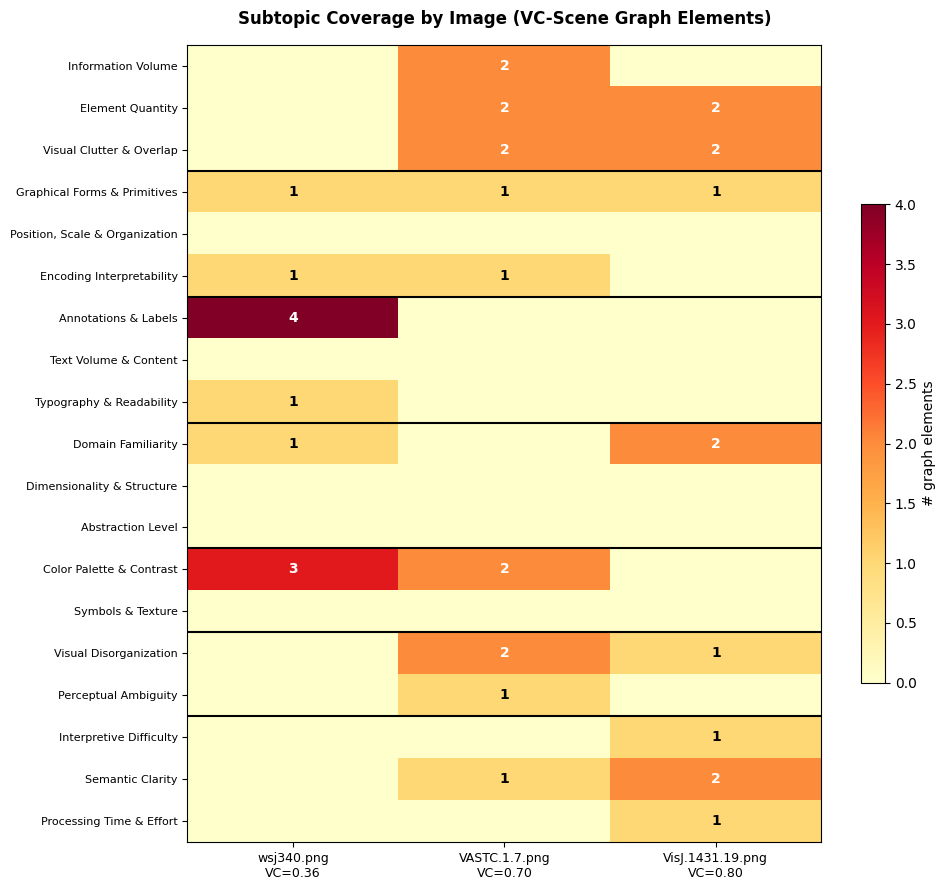

In [10]:
# ============================================================
# Subtopic coverage: which subtopics does each image's graph touch?
# ============================================================

all_subtopics = subtopics_df['SubTopic'].tolist()

coverage_data = {}
for img in EXAMPLE_IMAGES:
    canon = stage2_canonical[img]
    hit = Counter()
    for a in canon['attributes']:
        hit[a['subtopic']] += 1
    for r in canon['relationships']:
        hit[r['subtopic']] += 1
    coverage_data[img] = hit

# Build heatmap matrix
coverage_matrix = []
for st in all_subtopics:
    row = [coverage_data[img].get(st, 0) for img in EXAMPLE_IMAGES]
    coverage_matrix.append(row)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(coverage_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# Labels
vc_labels = [f"{img}\nVC={examples.loc[examples['imageName']==img, 'NormalizedVC'].values[0]:.2f}"
             for img in EXAMPLE_IMAGES]
ax.set_xticks(range(len(EXAMPLE_IMAGES)))
ax.set_xticklabels(vc_labels, fontsize=9)
ax.set_yticks(range(len(all_subtopics)))
ax.set_yticklabels(all_subtopics, fontsize=8)

# Add topic group separators
prev_topic = None
for i, st in enumerate(all_subtopics):
    topic = subtopics_df.loc[subtopics_df['SubTopic']==st, 'Topic'].values[0]
    if prev_topic and topic != prev_topic:
        ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
    prev_topic = topic

# Annotate cells with count
for i in range(len(all_subtopics)):
    for j in range(len(EXAMPLE_IMAGES)):
        val = coverage_matrix[i][j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val >= 2 else 'black')

ax.set_title('Subtopic Coverage by Image (VC-Scene Graph Elements)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='# graph elements', shrink=0.6)
plt.tight_layout()
plt.show()

---
## Summary & Observations

The three example scene graphs illustrate how the VC-Genome data model captures structural differences in visual complexity:

| Observation | Low VC (Bar, 0.36) | Medium VC (Node-link, 0.70) | High VC (Point, 0.80) |
|---|---|---|---|
| **Dominant sentiment** | Mostly (–) | Entirely (+) | Entirely (+) |
| **Graph structure** | Annotations *clarify* marks | Elements *obscure* each other | Layout *overwhelms* the whole |
| **Key predicates** | describes, clarifies, labels | fills, obscures, fails\_to\_explain | scattered\_across, lacks\_story, overwhelms |
| **Subtopic spread** | Narrow (annotations + color) | Wide (6 subtopics) | Wide (5+ subtopics) |

The sentiment ratio and subtopic coverage both increase with VC score, suggesting these graph metrics are viable proxies for perceived complexity. Stage 4 (not shown) would validate this correlation across all 520 images.